### Importing the libraries

In [98]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### Load Data :

In [99]:
df = pd.read_csv('Data.csv')
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


### Convert Date to datetime

In [100]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54170 entries, 0 to 54169
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DateTime       54170 non-null  datetime64[ns]
 1   Consumption    54170 non-null  int64         
 2   Production     54170 non-null  int64         
 3   Nuclear        54170 non-null  int64         
 4   Wind           54170 non-null  int64         
 5   Hydroelectric  54170 non-null  int64         
 6   Oil and Gas    54170 non-null  int64         
 7   Coal           54170 non-null  int64         
 8   Solar          54170 non-null  int64         
 9   Biomass        54170 non-null  int64         
dtypes: datetime64[ns](1), int64(9)
memory usage: 4.1 MB


### Check the Duplicated Data

In [101]:
def CheckDuplicated(Data):
    num_dup = Data.duplicated().sum()
    if num_dup > 0:
        print("Numer of deplicated is : ", num_dup)
        Data.drop_duplicates(inplace=True)
        print("Number of deplicated after drop is : ", Data.duplicated().sum())
    else:
        print("No duplicated values")

CheckDuplicated(df)

Numer of deplicated is :  4
Number of deplicated after drop is :  0


### Préparation des données temporelles :
1. Pourquoi l’ordre temporel est critique
2. Pourquoi on ne mélange pas les données (pas de shuffle)

In [102]:
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values("DateTime")
df.set_index("DateTime", inplace=True)

### Normalisation des données :
1. Pourquoi la normalisation est indispensable en Deep Learning
2. Pourquoi MinMax est souvent préféré à StandardScaler pour LSTM

In [103]:
scaled = MinMaxScaler(feature_range=(0,1))
columns_to_scale = ['Hydroelectric', 'Wind', 'Solar', 'Nuclear', 'Oil and Gas', 'Coal', 'Biomass', 'Production', 'Consumption']
df_normalized = df.copy()
df_normalized[columns_to_scale] = scaled.fit_transform(df[columns_to_scale])
df_normalized[columns_to_scale].describe()

,Hydroelectric,Wind,Solar,Nuclear,Oil and Gas,Coal,Biomass,Production,Consumption
count,54166.000000,54166.000000,54166.000000,54166.000000,54166.000000,54166.000000,54166.000000,54166.000000,54166.000000
mean,0.379830,0.281194,0.110709,0.804997,0.499416,0.380643,0.526927,0.481938,0.538558
std,0.159656,0.234947,0.165762,0.269492,0.222985,0.146118,0.191142,0.150047,0.156613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.259685,0.089531,0.000000,0.870391,0.341727,0.270593,0.388889,0.372543,0.416704
50%,0.353135,0.210434,0.001933,0.911732,0.520555,0.369353,0.527778,0.473326,0.530704
75%,0.473351,0.420515,0.194588,0.936313,0.675745,0.477857,0.666667,0.582090,0.649335
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Split Data X , Y :

1. Pourquoi un LSTM attend des données en 3D </br>
2. Signification de la forme : (samples, timesteps, features)

In [104]:
def preparer_donnees_prediction(data, window=24):
    X = []
    Y = []
    
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        Y.append(data[i, 0]) 
        
    return np.array(X), np.array(Y)

X, Y = preparer_donnees_prediction(df_normalized.values)

print(f"Forme de X : {X.shape}") 
print(f"Forme de y : {Y.shape}")

Forme de X : (54142, 24, 9)
Forme de y : (54142,)


### Split Train / Test :
1. Pourquoi on ne fait pas de traintestsplit classique </br>
2. Risque de fuite de données temporelles


In [105]:
split = int(0.8 * len(X))
Xtrain, Xtest = X[:split], X[split:]
Ytrain, Ytest = Y[:split], Y[split:]

if (Xtrain.shape[0] ==  Ytrain.shape[0]  and Xtest.shape[0] == Ytest.shape[0]):
    print('Good !!')

Good !!


### Architecture LSTM :
1. Impact du nombre d’unités LSTM
2. Différence entre 1 ou plusieurs couches LSTM

In [106]:
model = Sequential([
    LSTM(64, input_shape=(24, X.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer = "adam",
    loss="mse"
)

/media/lmobrmij/d70e3dc6-74e7-4c87-96bc-e4c3689c979a/lmobrmij/Projects/Pr-vision-de-la-Demande-nerg-tique/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Entrainement & Monitoring :
1. Courbe loss vs val_loss
2. Détection du surapprentissage


In [107]:
history = model.fit(
    Xtrain, Ytrain, validation_split = 0.2, epochs = 30, batch_size = 32
)

Epoch 1/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 0.0077 - val_loss: 0.0015
Epoch 2/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 0.0026 - val_loss: 8.9501e-04
Epoch 3/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.0018 - val_loss: 9.4095e-04
Epoch 4/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.0013 - val_loss: 6.1871e-04
Epoch 5/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.0010 - val_loss: 5.4772e-04
Epoch 6/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 8.9626e-04 - val_loss: 4.8361e-04
Epoch 7/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 8.0952e-04 - val_loss: 4.5814e-04
Epoch 8/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 7.3518e-04 - val_loss: 4.5676e-04
Epoch 9/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 6.9735e-04 - val_loss: 4.2417e-04
Epoch 10/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 6.4854e-04 - val_loss: 5.1094e-04
Epoch 11/30
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 

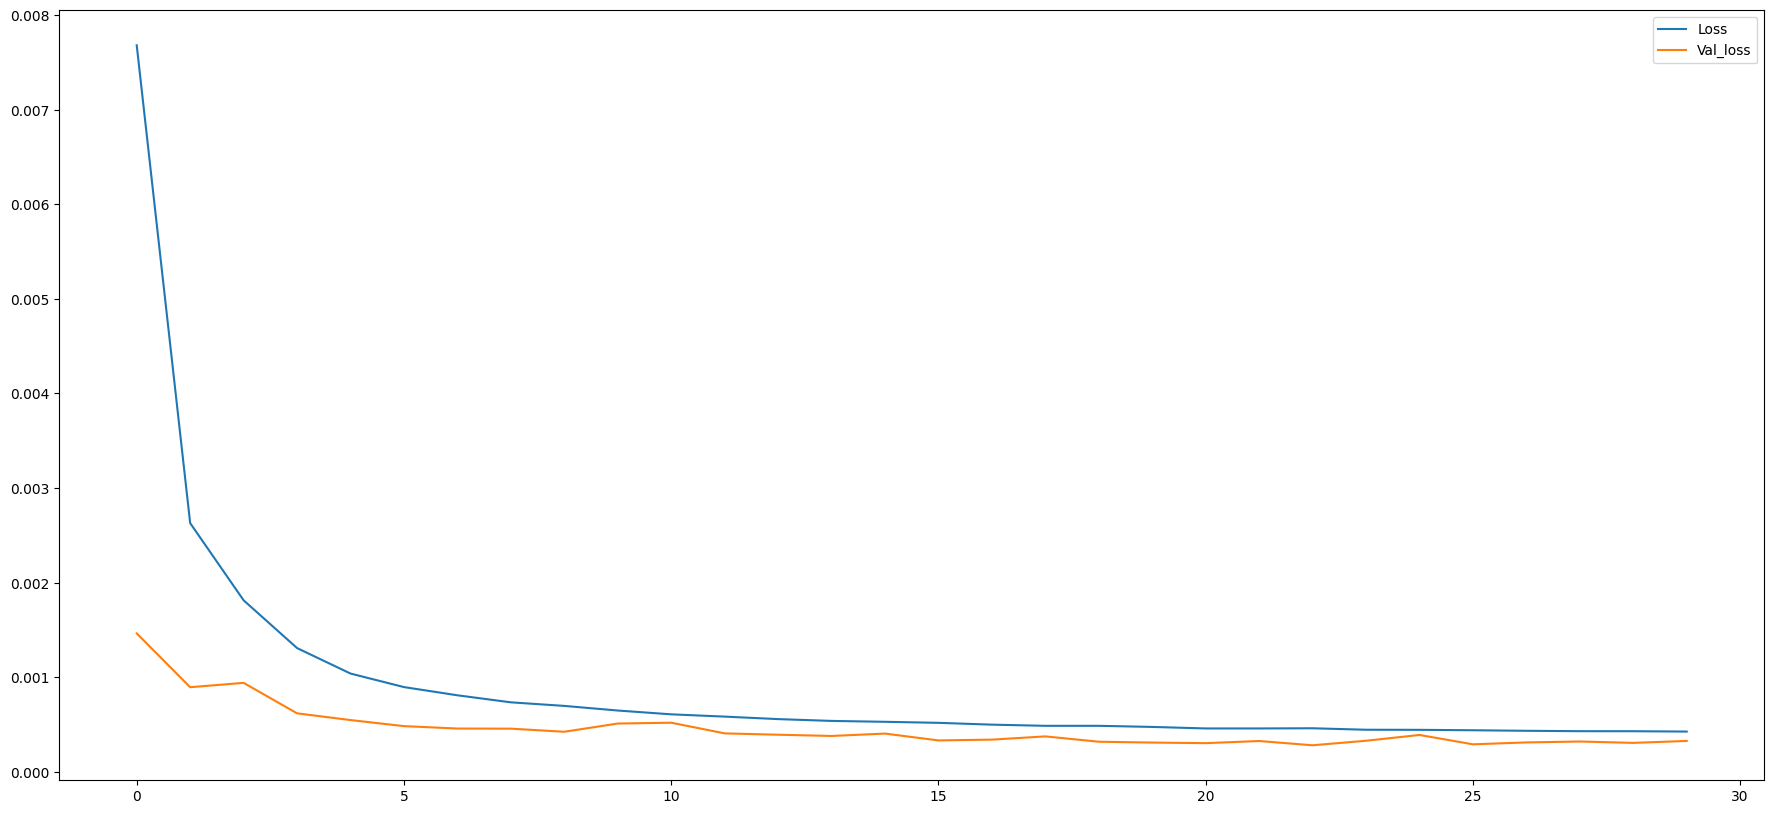

In [108]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(22,10))
plt.plot(loss, label='Loss')
plt.plot(val_loss, label='Val_loss')
plt.legend()
plt.show()

### Evaluation du modèle :

339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


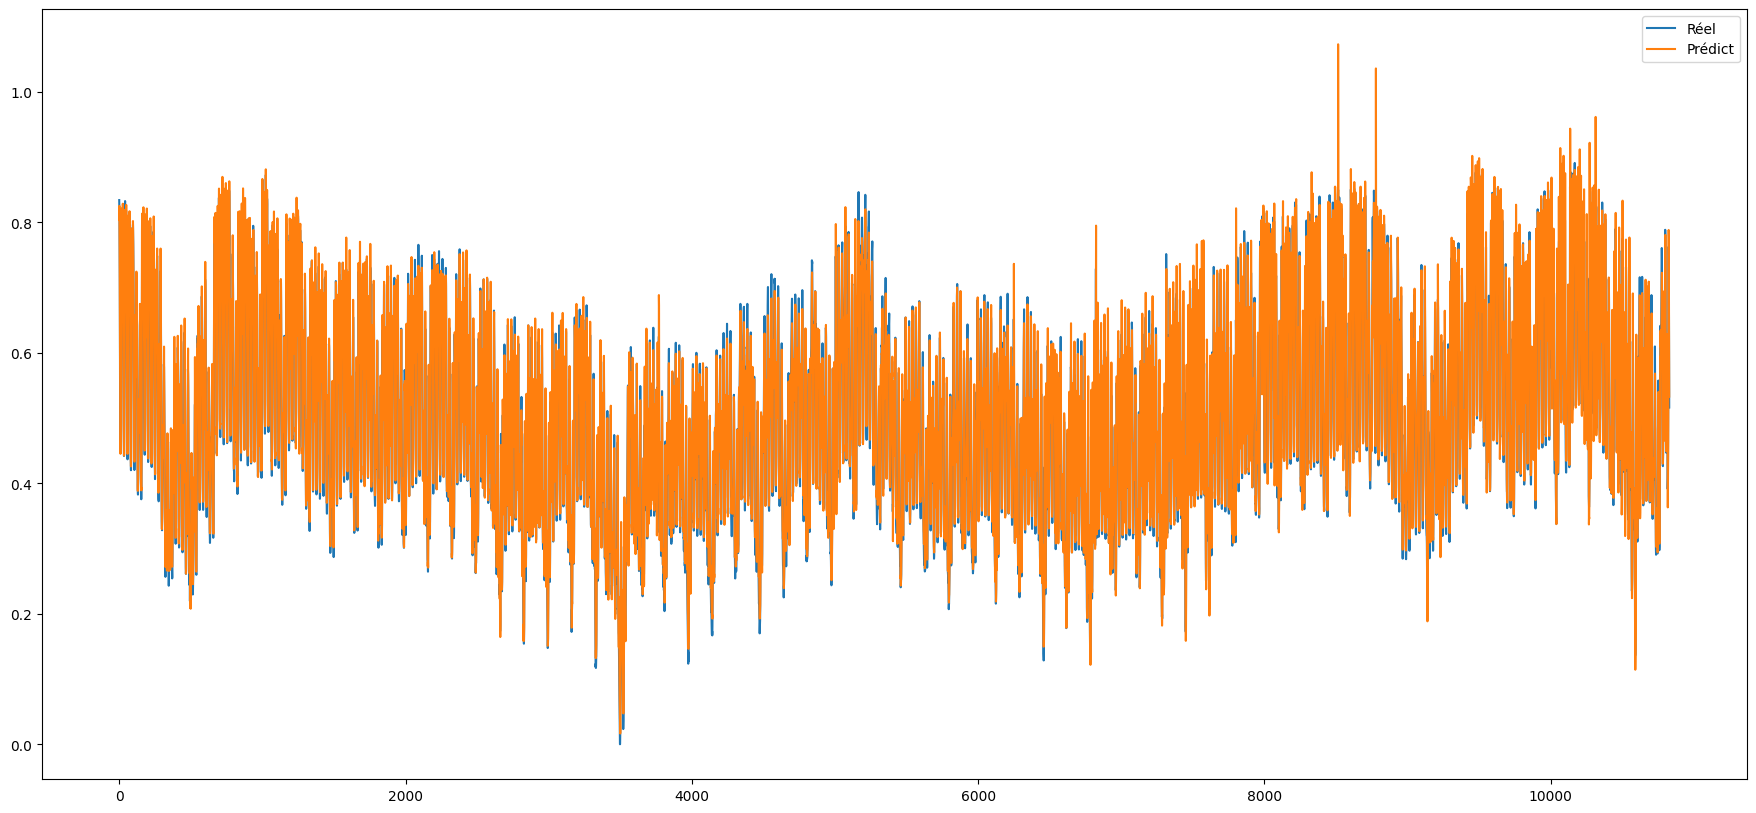

In [109]:
from cProfile import label
Ypred = model.predict(Xtest)
plt.figure(figsize=(22,10))
plt.plot(Ytest, label="Réel")
plt.plot(Ypred, label="Prédict")
plt.legend()
plt.show()